# Shor Code
The Shor code protects 1 logical qubit using 9 physical qubits. It combines a 3-qubit bit-flip repetition code with a 3-qubit phase-flip repetition code.

In [1]:
from qec.shor import encode_shor, measure_syndrome_shor, decode_shor, run_shor
from qec.noise import make_noise_model
from qec.visualize import plot_circuit, plot_threshold
from qec.benchmark import sweep_error_rates
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

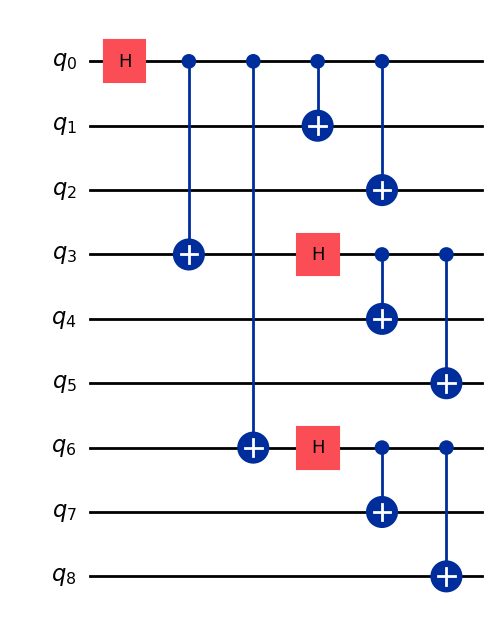

In [2]:
q = QuantumRegister(9, 'q')
qc = QuantumCircuit(q)
encode_shor(qc, q)
fig = plot_circuit(qc, "shor_encoding")
display(fig)

In [3]:
anc = QuantumRegister(6, 'anc')
creg = ClassicalRegister(6, 'syndrome')
qc2 = QuantumCircuit(q, anc, creg)
encode_shor(qc2, q)
qc2.x(q[0])
measure_syndrome_shor(qc2, q, anc, creg)
from qiskit_aer import AerSimulator
result = AerSimulator().run(qc2, shots=1).result()
syndrome = list(result.get_counts().keys())[0]
print("Syndrome:", syndrome)
correction = decode_shor([int(b) for b in syndrome])
print("Correction:", correction)

Syndrome: 000001
Correction: (8, 'X')


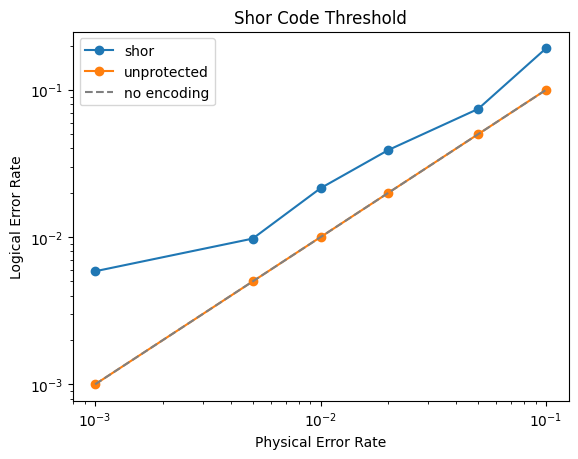

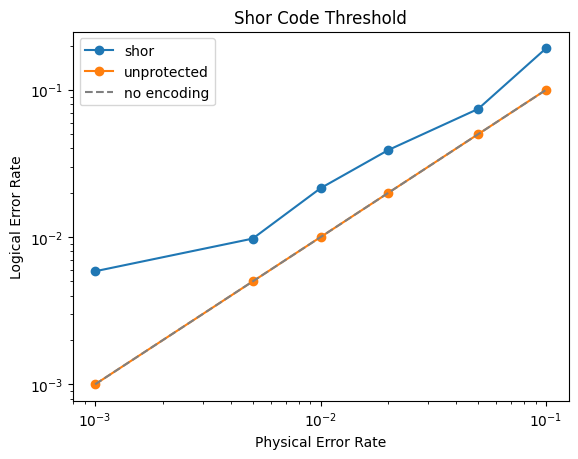

In [4]:
import numpy as np
error_rates = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
df = sweep_error_rates("shor", error_rates, "depolarizing", shots=512)
import pandas as pd
baseline = pd.DataFrame({"p_physical": error_rates, "p_logical": error_rates, "code": "unprotected"})
df["code"] = "shor"
combined = pd.concat([df, baseline])
fig = plot_threshold(combined, "Shor Code Threshold")
display(fig)